# Task 4 — Sentiment Analysis

## CodeAlpha Data Analytics Internship

This notebook performs sentiment analysis on the Amazon Fine Food Reviews dataset.

The objective is to analyze the emotional polarity of customer reviews and classify review text into positive, neutral, and negative sentiment categories.

### Analysis Objectives

1. Prepare customer review text for sentiment analysis.
2. Apply an NLP-based sentiment analysis method.
3. Classify reviews into positive, neutral, and negative sentiment.
4. Examine the distribution of sentiment across customer reviews.
5. Compare sentiment results with customer star ratings.
6. Identify patterns that can provide useful customer and product insights.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [25]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from parse_reviews import parse_reviews

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Reviews.csv"

df = parse_reviews(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 568,454
Columns: 8


In [26]:
print("Available columns:")
print(df.columns.tolist())

print("\nSample review:")
print(df["review/text"].iloc[0])

Available columns:
['product/productId', 'review/userId', 'review/profileName', 'review/helpfulness', 'review/score', 'review/time', 'review/summary', 'review/text']

Sample review:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.


In [27]:
df_sentiment = df.copy()

# Keep only reviews with usable text
df_sentiment = df_sentiment.dropna(
    subset=["review/text"]
).copy()

# Convert review text to string
df_sentiment["review_text"] = (
    df_sentiment["review/text"]
    .astype(str)
    .str.strip()
)

# Remove empty reviews
df_sentiment = df_sentiment[
    df_sentiment["review_text"] != ""
].copy()

print("Sentiment analysis data prepared.")
print(f"Reviews available for sentiment analysis: {len(df_sentiment):,}")

Sentiment analysis data prepared.
Reviews available for sentiment analysis: 568,454


In [28]:
%pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.


In [29]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

print("VADER sentiment analyzer loaded successfully.")

VADER sentiment analyzer loaded successfully.


In [30]:
sample_text = df_sentiment["review_text"].iloc[0]

sample_scores = analyzer.polarity_scores(sample_text)

print("Sample review:")
print(sample_text)

print("\nVADER sentiment scores:")
print(sample_scores)

Sample review:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

VADER sentiment scores:
{'neg': 0.0, 'neu': 0.711, 'pos': 0.289, 'compound': 0.9441}


In [31]:
def classify_sentiment(compound_score):
    """
    Classify a VADER compound sentiment score
    as Positive, Neutral, or Negative.
    """

    if compound_score >= 0.05:
        return "Positive"
    elif compound_score <= -0.05:
        return "Negative"
    else:
        return "Neutral"


# Test the classification rule
test_scores = [-0.80, -0.02, 0.00, 0.04, 0.75]

for score in test_scores:
    print(score, "->", classify_sentiment(score))

-0.8 -> Negative
-0.02 -> Neutral
0.0 -> Neutral
0.04 -> Neutral
0.75 -> Positive


In [32]:
def get_compound_score(text):
    """
    Return the VADER compound sentiment score for a review.
    """
    return analyzer.polarity_scores(text)["compound"]


df_sentiment["compound_score"] = (
    df_sentiment["review_text"]
    .apply(get_compound_score)
)

print("Sentiment scoring completed.")
print(
    df_sentiment["compound_score"]
    .describe()
)

Sentiment scoring completed.
count    568454.000000
mean          0.661974
std           0.454597
min          -0.999400
25%           0.605400
50%           0.861600
75%           0.944900
max           0.999900
Name: compound_score, dtype: float64


In [33]:
df_sentiment["sentiment"] = (
    df_sentiment["compound_score"]
    .apply(classify_sentiment)
)

print("Sentiment classification completed.")

print("\nSentiment counts:")
print(
    df_sentiment["sentiment"]
    .value_counts()
)

Sentiment classification completed.

Sentiment counts:
sentiment
Positive    501361
Negative     55365
Neutral      11728
Name: count, dtype: int64


In [34]:
sentiment_summary = (
    df_sentiment["sentiment"]
    .value_counts()
    .to_frame("Review Count")
)

sentiment_summary["Percentage"] = (
    sentiment_summary["Review Count"]
    / sentiment_summary["Review Count"].sum()
    * 100
)

sentiment_summary["Percentage"] = (
    sentiment_summary["Percentage"]
    .round(2)
)

sentiment_summary

,Review Count,Percentage
sentiment,,
Positive,501361,88.20
Negative,55365,9.74
Neutral,11728,2.06


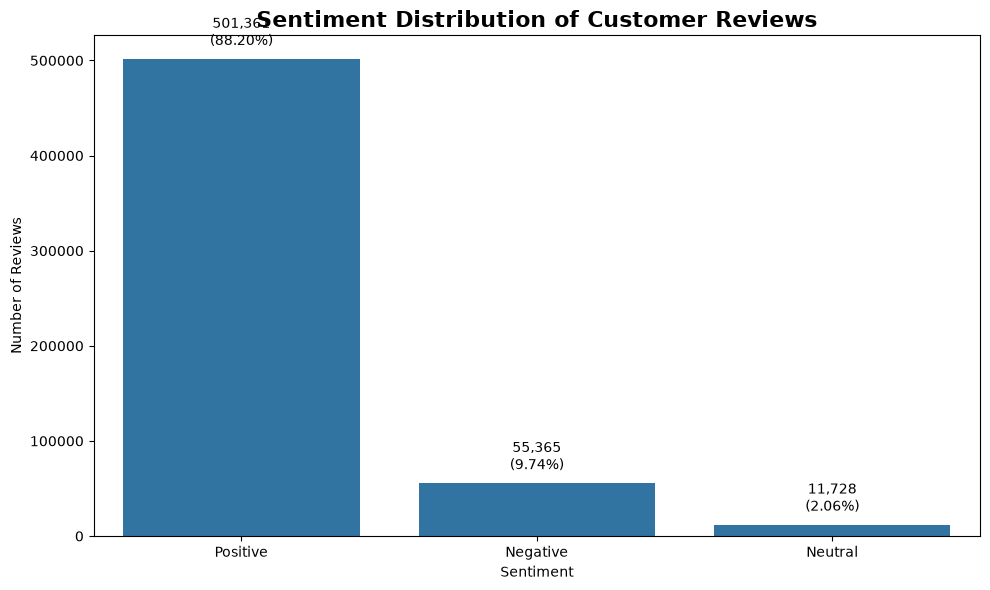

In [35]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=sentiment_summary.index,
    y=sentiment_summary["Review Count"]
)

plt.title(
    "Sentiment Distribution of Customer Reviews",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for i, (count, percentage) in enumerate(
    zip(
        sentiment_summary["Review Count"],
        sentiment_summary["Percentage"]
    )
):
    ax.text(
        i,
        count + 10000,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [36]:
df_sentiment["rating"] = pd.to_numeric(
    df_sentiment["review/score"],
    errors="coerce"
)

sentiment_by_rating = (
    df_sentiment
    .groupby(["rating", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

sentiment_by_rating

sentiment,Negative,Neutral,Positive
rating,,,
1.0,23600,2643,26025
2.0,8985,1389,19395
3.0,7262,1631,33747
4.0,4593,1395,74667
5.0,10925,4670,347527


In [37]:
sentiment_by_rating_pct = (
    sentiment_by_rating
    .div(sentiment_by_rating.sum(axis=1), axis=0)
    * 100
)

sentiment_by_rating_pct = (
    sentiment_by_rating_pct
    .round(2)
)

sentiment_by_rating_pct

sentiment,Negative,Neutral,Positive
rating,,,
1.0,45.15,5.06,49.79
2.0,30.18,4.67,65.15
3.0,17.03,3.83,79.14
4.0,5.69,1.73,92.58
5.0,3.01,1.29,95.71


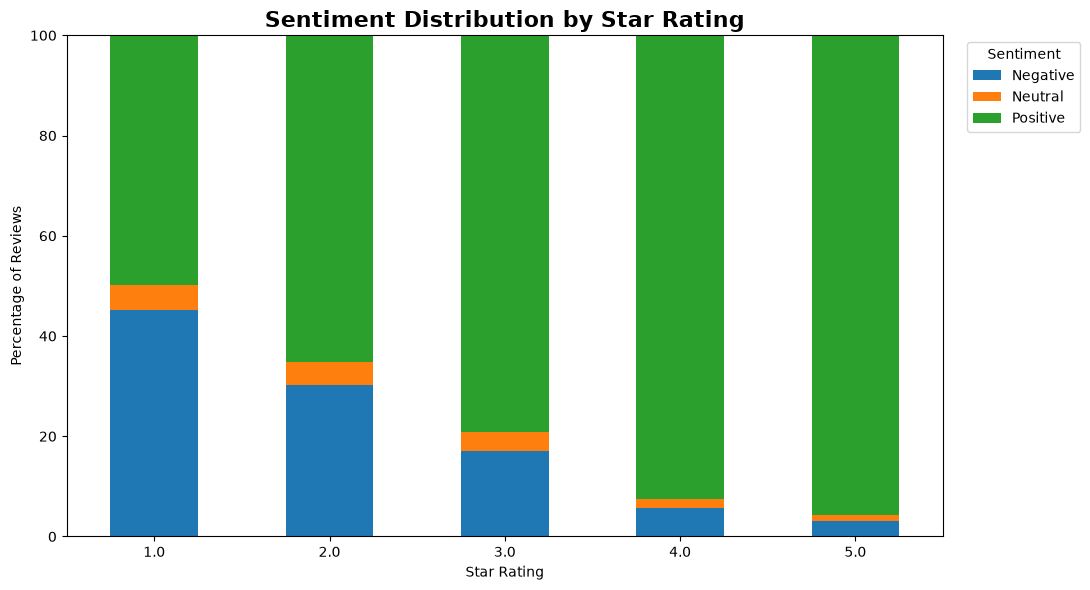

In [38]:
ax = sentiment_by_rating_pct[
    ["Negative", "Neutral", "Positive"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title(
    "Sentiment Distribution by Star Rating",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Star Rating")
plt.ylabel("Percentage of Reviews")

plt.xticks(
    rotation=0
)

plt.ylim(0, 100)

plt.legend(
    title="Sentiment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [39]:
def rating_group(rating):
    if rating <= 2:
        return "Low Rating"
    elif rating == 3:
        return "Middle Rating"
    else:
        return "High Rating"


df_sentiment["rating_group"] = (
    df_sentiment["rating"]
    .apply(rating_group)
)

rating_group_sentiment = (
    df_sentiment
    .groupby(["rating_group", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

rating_group_sentiment_pct = (
    rating_group_sentiment
    .div(rating_group_sentiment.sum(axis=1), axis=0)
    * 100
).round(2)

rating_group_sentiment_pct

sentiment,Negative,Neutral,Positive
rating_group,,,
High Rating,3.50,1.37,95.14
Low Rating,39.72,4.91,55.37
Middle Rating,17.03,3.83,79.14


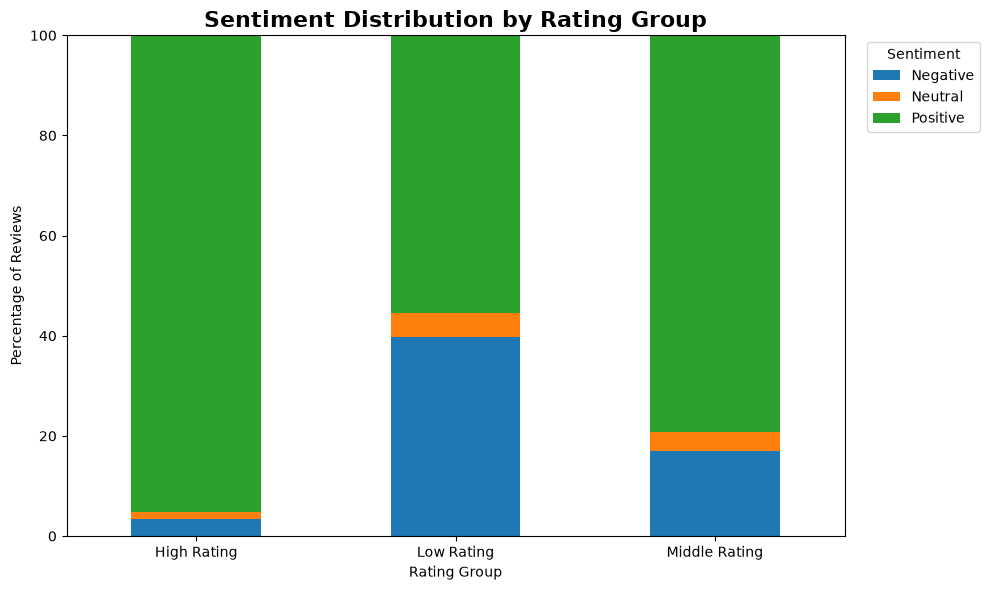

In [40]:
ax = rating_group_sentiment_pct[
    ["Negative", "Neutral", "Positive"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    "Sentiment Distribution by Rating Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Rating Group")
plt.ylabel("Percentage of Reviews")

plt.xticks(
    rotation=0
)

plt.ylim(0, 100)

plt.legend(
    title="Sentiment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [41]:
strongest_positive = (
    df_sentiment[
        ["review/score", "compound_score", "review_text"]
    ]
    .sort_values(
        "compound_score",
        ascending=False
    )
    .head(5)
)

strongest_negative = (
    df_sentiment[
        ["review/score", "compound_score", "review_text"]
    ]
    .sort_values(
        "compound_score",
        ascending=True
    )
    .head(5)
)

print("Strongest Positive Reviews")
print("=" * 80)

for index, row in strongest_positive.iterrows():
    print(f"\nStar Rating: {row['review/score']}")
    print(f"Compound Score: {row['compound_score']}")
    print(f"Review: {row['review_text'][:500]}")

print("\n\nStrongest Negative Reviews")
print("=" * 80)

for index, row in strongest_negative.iterrows():
    print(f"\nStar Rating: {row['review/score']}")
    print(f"Compound Score: {row['compound_score']}")
    print(f"Review: {row['review_text'][:500]}")

Strongest Positive Reviews

Star Rating: 5.0
Compound Score: 0.9999
Review: *********************************************************<br /> UPDATE:  READ THE UPDATE BELOW FIRST. Thanks. (June 15 and August 3, 2012)<br />*********************************************************<br />  I WAS, BUT NO MORE (actively anyway). We have four cats: two ("normals") who eat about anything, one with kidney disease (CRF/CKD) and accompanying reduced appetite, and one that has picky (and weird) tastes.  In the process of trying to find an appetite stimulant for the mom-cat (with CRF/

Star Rating: 4.0
Compound Score: 0.9999
Review: I have really been into Yogi tea and trying them all! I have all the green teas and after a month of testing them I conclude that Rejuvenation tastes the best. It has a natural peach and lemon flavor that is very natural and mild. Most say the Simply Green tastes the best but to me it was far too boring. I got used to all the special herbs and natural flavors and the Simp

In [42]:
def expected_sentiment_from_rating(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"


df_sentiment["expected_sentiment"] = (
    df_sentiment["rating"]
    .apply(expected_sentiment_from_rating)
)

df_sentiment["sentiment_agreement"] = (
    df_sentiment["sentiment"]
    == df_sentiment["expected_sentiment"]
)

agreement_rate = (
    df_sentiment["sentiment_agreement"]
    .mean()
    * 100
)

print(
    f"Sentiment-rating agreement: {agreement_rate:.2f}%"
)

print("\nAgreement counts:")
print(
    df_sentiment["sentiment_agreement"]
    .value_counts()
)

Sentiment-rating agreement: 80.29%

Agreement counts:
sentiment_agreement
True     456410
False    112044
Name: count, dtype: int64


In [43]:
disagreement_by_rating = (
    df_sentiment[
        ~df_sentiment["sentiment_agreement"]
    ]
    .groupby(["rating", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

print("Sentiment disagreements by star rating:")
print(disagreement_by_rating)

Sentiment disagreements by star rating:
sentiment  Negative  Neutral  Positive
rating                                
1.0               0     2643     26025
2.0               0     1389     19395
3.0            7262        0     33747
4.0            4593     1395         0
5.0           10925     4670         0


In [44]:
disagreement_pct_by_rating = (
    df_sentiment
    .groupby("rating")["sentiment_agreement"]
    .apply(lambda x: (~x).mean() * 100)
    .round(2)
)

print("Disagreement percentage by star rating:")
print(disagreement_pct_by_rating)

Disagreement percentage by star rating:
rating
1.0    54.85
2.0    69.82
3.0    96.17
4.0     7.42
5.0     4.29
Name: sentiment_agreement, dtype: float64


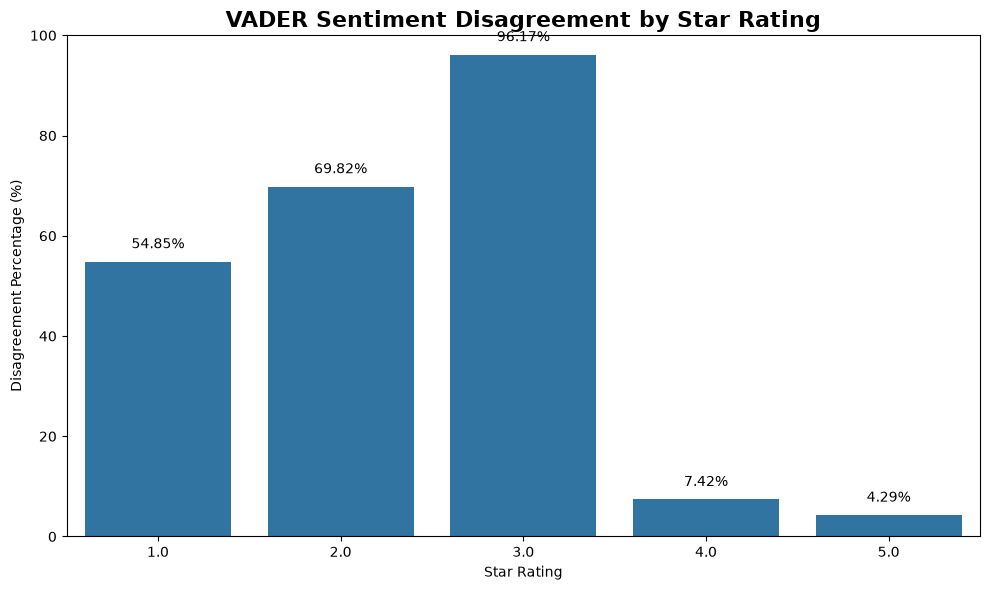

In [45]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=disagreement_pct_by_rating.index.astype(str),
    y=disagreement_pct_by_rating.values
)

plt.title(
    "VADER Sentiment Disagreement by Star Rating",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Star Rating")
plt.ylabel("Disagreement Percentage (%)")

plt.ylim(0, 100)

for i, value in enumerate(disagreement_pct_by_rating.values):
    ax.text(
        i,
        value + 2,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [46]:
import re

def clean_review_text(text):
    """
    Remove HTML tags and normalize whitespace
    for easier reading of review examples.
    """
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


df_sentiment["clean_text"] = (
    df_sentiment["review_text"]
    .apply(clean_review_text)
)

strongest_positive_examples = (
    df_sentiment[
        [
            "rating",
            "compound_score",
            "sentiment",
            "clean_text"
        ]
    ]
    .sort_values(
        "compound_score",
        ascending=False
    )
    .head(3)
)

strongest_negative_examples = (
    df_sentiment[
        [
            "rating",
            "compound_score",
            "sentiment",
            "clean_text"
        ]
    ]
    .sort_values(
        "compound_score",
        ascending=True
    )
    .head(3)
)

print("Strongest Positive Examples")
print("=" * 100)

for _, row in strongest_positive_examples.iterrows():
    print(f"\nRating: {row['rating']}")
    print(f"Sentiment: {row['sentiment']}")
    print(f"Compound Score: {row['compound_score']}")
    print(f"Review: {row['clean_text'][:600]}")

print("\n\nStrongest Negative Examples")
print("=" * 100)

for _, row in strongest_negative_examples.iterrows():
    print(f"\nRating: {row['rating']}")
    print(f"Sentiment: {row['sentiment']}")
    print(f"Compound Score: {row['compound_score']}")
    print(f"Review: {row['clean_text'][:600]}")

Strongest Positive Examples

Rating: 5.0
Sentiment: Positive
Compound Score: 0.9999
Review: ********************************************************* UPDATE: READ THE UPDATE BELOW FIRST. Thanks. (June 15 and August 3, 2012) ********************************************************* I WAS, BUT NO MORE (actively anyway). We have four cats: two ("normals") who eat about anything, one with kidney disease (CRF/CKD) and accompanying reduced appetite, and one that has picky (and weird) tastes. In the process of trying to find an appetite stimulant for the mom-cat (with CRF/CKD) I tried out several products on her and the others (the kids) as well. Here are the results of this less than scien

Rating: 4.0
Sentiment: Positive
Compound Score: 0.9999
Review: I have really been into Yogi tea and trying them all! I have all the green teas and after a month of testing them I conclude that Rejuvenation tastes the best. It has a natural peach and lemon flavor that is very natural and mild. Most say the

## Key Insights and Findings

### Overall Sentiment

VADER classified 568,454 customer reviews into three sentiment categories:

- **Positive:** 501,361 reviews (88.20%)
- **Negative:** 55,365 reviews (9.74%)
- **Neutral:** 11,728 reviews (2.06%)

The dataset therefore contains a strong overall positive sentiment distribution.

### Relationship Between Sentiment and Star Rating

Sentiment generally becomes more positive as star ratings increase.

- **1-star reviews:** 49.79% positive and 45.15% negative
- **2-star reviews:** 65.15% positive and 30.18% negative
- **3-star reviews:** 79.14% positive and 17.03% negative
- **4-star reviews:** 92.58% positive and 5.69% negative
- **5-star reviews:** 95.71% positive and 3.01% negative

The results show a clear directional relationship between higher star ratings and more positive VADER classifications.

### Agreement With Rating-Based Sentiment

Using a simple rating-based expectation:

- 1–2 stars → Negative
- 3 stars → Neutral
- 4–5 stars → Positive

VADER sentiment agreed with these categories for **80.29% of reviews**.

However, this should not be interpreted as formal model accuracy because star ratings are not independent ground-truth sentiment labels.

### Sentiment Disagreement

The disagreement rate varied substantially by rating:

- 1-star: 54.85%
- 2-star: 69.82%
- 3-star: 96.17%
- 4-star: 7.42%
- 5-star: 4.29%

The particularly high disagreement for 3-star reviews shows that a middle star rating does not necessarily correspond to neutral language. Customers may describe both positive and negative aspects while still assigning a middle rating.

### Qualitative Review Analysis

Examples with extreme VADER scores showed that the sentiment classifier can identify strongly emotional language. However, some reviews contained mixed sentiment, quotations, historical information, or externally written content.

For example, some 5-star reviews received strongly negative VADER scores because the text contained negative language even though the customer's rating was positive.

### Limitations

VADER is a rule-based, lexicon-based sentiment analysis method. It is useful for efficiently analyzing a large collection of reviews, but it does not fully understand context.

Important limitations include:

- Mixed positive and negative opinions within the same review
- Negation and context
- Sarcasm or indirect language
- Product-specific terminology
- Quoted or externally sourced text
- Reviews where the written text and star rating express different aspects of the customer's experience

Therefore, the sentiment results should be interpreted as **automated sentiment classifications**, rather than perfect representations of customer opinion.

### Overall Conclusion

The sentiment analysis reveals that the Amazon Fine Food Reviews dataset is strongly positive overall, with 88.20% of reviews classified as positive by VADER.

There is also a clear relationship between higher star ratings and positive sentiment classifications. At the same time, the disagreement analysis demonstrates that automated lexicon-based sentiment analysis has important limitations, particularly for reviews with mixed or context-dependent language.

These findings demonstrate how NLP-based sentiment analysis can be used to extract customer sentiment patterns from a large review dataset while also highlighting the importance of evaluating the limitations of the chosen analytical method.